In [6]:
# Import necessary libraries
import os
import pandas as pd
import anndata as ad
import numpy as np
import sys 
import datetime
import pickle
import gffutils
# Add the directory containing find_intron_clusters_v3.py to Python path
LEAFLET_SRC = '/gpfs/commons/home/kisaev/Leaflet-private/src'
sys.path.append(LEAFLET_SRC)

# Now import your modules
from clustering.find_intron_clusters_v3 import (
    JunctionReader,
    JunctionAnalyzer, 
    GenomeDB, 
    ATSEAnalyzer
)

import visualization.IsovizPy as ja


ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-03-13_21-45-15.txt.gz"

# Load the ATSE file
ATSE = pd.read_csv(ATSE_file, sep = "\t", compression = "gzip")

In [2]:
ATSE

,event_id,gene_id,gene_name,transcripts,transcript_types,num_junctions,event_type,annotation_status,junction_id,chrom,start,end,strand,cells,total_score,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSG00000241860.7,ENSG00000241860,ENST00000466557.6,lncRNA,4,alternative_3_prime,both,chr1_164791_165883_-,chr1,164791,165883,-,1004,6177,GT-AG,GT,AG,1.0,0.0
1,ATSE_0,ENSG00000241860.7,ENSG00000241860,ENST00000466557.6,lncRNA,4,alternative_3_prime,five_prime,chr1_123714_165883_-,chr1,123714,165883,-,21,609,GT-AG,GT,AG,1.0,NaN
2,ATSE_0,ENSG00000241860.7,ENSG00000241860,ENST00000466557.6,lncRNA,4,alternative_3_prime,five_prime,chr1_124838_165883_-,chr1,124838,165883,-,16,315,GT-AG,GT,AG,1.0,NaN
3,ATSE_0,ENSG00000241860.7,ENSG00000241860,ENST00000466557.6,lncRNA,4,alternative_3_prime,five_prime,chr1_165283_165883_-,chr1,165283,165883,-,188,747,GT-AG,GT,AG,1.0,NaN
4,ATSE_1,ENSG00000241860.7,ENSG00000241860,"ENST00000491962.1,ENST00000466557.6",lncRNA,10,complex,both,chr1_168165_168609_-,chr1,168165,168609,-,915,5478,GT-AG,GT,AG,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253598,ATSE_50650,ENSG00000237126.8,ENSG00000237126,ENST00000415506.6,lncRNA,2,alternative_3_prime,both,chr2_232582141_232584305_-,chr2,232582141,232584305,-,11,215,GT-AG,GT,AG,1.0,0.0
253599,ATSE_50651,ENSG00000260861.6,ENSG00000260861,ENST00000567028.5,protein_coding,2,alternative_5_prime,both,chr20_1578694_1588559_-,chr20,1578694,1588559,-,12,736,GT-AG,GT,AG,1.0,0.0
253600,ATSE_50651,ENSG00000260861.6,ENSG00000260861,"ENST00000564763.1,ENST00000567028.5",protein_coding,2,alternative_5_prime,both,chr20_1578694_1619868_-,chr20,1578694,1619868,-,10,425,GT-AG,GT,AG,1.0,0.0
253601,ATSE_50652,ENSG00000175879.9,HOXD8,"ENST00000429017.2,ENST00000450510.2",protein_coding,2,alternative_3_prime,both,chr2_176130943_176131319_+,chr2,176130943,176131319,+,11,563,GT-AG,GT,AG,0.0,1.0


In [22]:
# find junctions that are "unique" map to just one transcript 
# if split transcripts column by "," and count the number of elements, if it is 1, then it is unique
ATSE["num_transcripts"] = ATSE["transcripts"].apply(lambda x: len(x.split(",")))
ATSE_unique = ATSE[ATSE["num_transcripts"] == 1]

# Keep only protein_coding trancsript_type
ATSE_unique = ATSE_unique[ATSE_unique["transcript_types"] == "protein_coding"]

# Add new count for how many junctions per atse event_id
ATSE_unique["num_junctions_unique"] = ATSE_unique.groupby("event_id")["event_id"].transform("count")

# keep only atses where new_junction_unique is same as num_junctions
ATSE_unique = ATSE_unique[ATSE_unique["num_junctions_unique"] == ATSE_unique["num_junctions"]]
ATSE_unique

,event_id,gene_id,gene_name,transcripts,transcript_types,num_junctions,event_type,annotation_status,junction_id,chrom,...,strand,cells,total_score,splice_motif,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime,num_transcripts,num_junctions_unique
69,ATSE_10,ENSG00000131591.18,C1orf159,ENST00000379339.5,protein_coding,2,alternative_5_prime,three_prime,chr1_1087204_1087497_-,chr1,...,-,20,163,GT-AG,GT,AG,5.0,0.0,1,2
70,ATSE_10,ENSG00000131591.18,C1orf159,ENST00000379339.5,protein_coding,2,alternative_5_prime,both,chr1_1087204_1087501_-,chr1,...,-,1816,14519,GT-AG,GT,AG,1.0,0.0,1,2
176,ATSE_32,ENSG00000248333.9,CDK11B,ENST00000341832.11,protein_coding,2,alternative_5_prime,three_prime,chr1_1637513_1637633_-,chr1,...,-,24,204,GC-AG,GC,AG,NaN,0.0,1,2
177,ATSE_32,ENSG00000248333.9,CDK11B,ENST00000341832.11,protein_coding,2,alternative_5_prime,both,chr1_1637513_1637761_-,chr1,...,-,693,8116,GT-AG,GT,AG,1.0,0.0,1,2
203,ATSE_36,ENSG00000008128.23,CDK11A,ENST00000404249.8,protein_coding,2,alternative_5_prime,both,chr1_1704655_1704903_-,chr1,...,-,399,1839,GT-AG,GT,AG,1.0,0.0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253578,ATSE_50642,ENSG00000066405.13,CLDN18,ENST00000343735.8,protein_coding,3,exon_skip,both,chr3_138023822_138029796_+,chr3,...,+,10,109,GT-AG,GT,AG,0.0,1.0,1,3
253579,ATSE_50642,ENSG00000066405.13,CLDN18,ENST00000343735.8,protein_coding,3,exon_skip,both,chr3_138023822_138024606_+,chr3,...,+,22,1756,GT-AG,GT,AG,0.0,1.0,1,3
253580,ATSE_50643,ENSG00000182795.13,C1orf116,ENST00000359470.6,protein_coding,3,complex,both,chr1_207025064_207027493_-,chr1,...,-,16,324,GT-AG,GT,AG,1.0,0.0,1,3
253581,ATSE_50643,ENSG00000182795.13,C1orf116,ENST00000359470.6,protein_coding,3,complex,both,chr1_207025064_207032578_-,chr1,...,-,11,317,GT-AG,GT,AG,1.0,0.0,1,3


/scratch/ipykernel_2682375/360160227.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juncs["usage_ratio"] = 0
/scratch/ipykernel_2682375/360160227.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juncs["Cluster"] = juncs["event_id"]


          event_id            gene_id gene_name  \
253601  ATSE_50652  ENSG00000175879.9     HOXD8   
253602  ATSE_50652  ENSG00000175879.9     HOXD8   

                                transcripts transcript_types  num_junctions  \
253601  ENST00000429017.2,ENST00000450510.2   protein_coding              2   
253602                    ENST00000429017.2   protein_coding              2   

                 event_type annotation_status                 junction_id  \
253601  alternative_3_prime              both  chr2_176130943_176131319_+   
253602  alternative_3_prime              both  chr2_176130943_176131316_+   

       chrom  ...        end  strand cells  total_score  splice_motif  \
253601  chr2  ...  176131319       +    11          563         GT-AG   
253602  chr2  ...  176131316       +    18          944         GT-AG   

       donor_seq acceptor_seq position_off_5_prime  position_off_3_prime  \
253601        GT           AG                  0.0                   1.0   
2536

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  4.43it/s]

Plot saved to HOXD8_no_usage_no_lines_20250317.pdf!


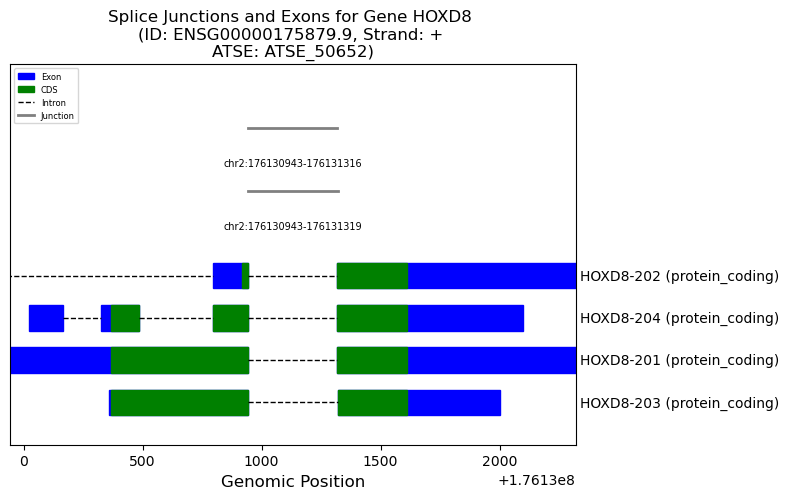

In [29]:
# visualize ATSE 
# # Visualize random ATSEs
db = gffutils.FeatureDB("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/v45hg38", keep_order=True)

atse_event = "ATSE_50652"
juncs = ATSE[ATSE["event_id"]==atse_event]
print(juncs) 

juncs["usage_ratio"] = 0
juncs["Cluster"] = juncs["event_id"]
splice_junctions = ja.convert_junction_ids(juncs)

# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
ja.plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, base_width=8, trans_height=1, show_usage=False, show_junc_lines=False)

In [31]:
splice_junctions

[{'chrom': 'chr2',
  'start': 176130943,
  'end': 176131319,
  'name': 'junction_253602',
  'strand': '+',
  'usage_ratio': 0},
 {'chrom': 'chr2',
  'start': 176130943,
  'end': 176131316,
  'name': 'junction_253603',
  'strand': '+',
  'usage_ratio': 0}]

In [30]:
transcript_data

{'ENST00000450510.2': {'transcript_id': 'ENST00000450510.2',
  'transcript_name': 'HOXD8-203',
  'transcript_type': 'protein_coding',
  'chromosome': 'chr2',
  'exons': [(176130357, 176130943), (176131320, 176132000)],
  'cds': [(176130367, 176130943), (176131320, 176131609)],
  'strand': '+'},
 'ENST00000313173.6': {'transcript_id': 'ENST00000313173.6',
  'transcript_name': 'HOXD8-201',
  'transcript_type': 'protein_coding',
  'chromosome': 'chr2',
  'exons': [(176129705, 176130943), (176131317, 176132695)],
  'cds': [(176130367, 176130943), (176131317, 176131609)],
  'strand': '+'},
 'ENST00000544999.2': {'transcript_id': 'ENST00000544999.2',
  'transcript_name': 'HOXD8-204',
  'transcript_type': 'protein_coding',
  'chromosome': 'chr2',
  'exons': [(176130022, 176130167),
   (176130327, 176130483),
   (176130796, 176130943),
   (176131317, 176132100)],
  'cds': [(176130367, 176130483),
   (176130796, 176130943),
   (176131317, 176131609)],
  'strand': '+'},
 'ENST00000429017.2': {'t